In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import skew
from pytorch_tabnet.tab_model import TabNetClassifier
import lightgbm as lgb
import h2o
from h2o.automl import H2OAutoML
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier

In [4]:
column_names = {
    'PS1': ['PS1'], 'PS2': ['PS2'], 'PS3': ['PS3'], 'PS4': ['PS4'], 'PS5': ['PS5'], 'PS6': ['PS6'],
    'EPS1': ['EPS1'], 'FS1': ['FS1'], 'FS2': ['FS2'], 'TS1': ['TS1'], 'TS2': ['TS2'], 'TS3': ['TS3'], 'TS4': ['TS4'],
    'VS1': ['VS1'], 'SE': ['SE'], 'CE': ['CE'], 'CP': ['CP']
}

chunk_size = 10000 
data_chunks = []

for key in column_names.keys():
    file_path = f"/kaggle/input/hydraulic-system-uci/Dataset/{key}.txt"
    chunk_list = []  
    
    for chunk in pd.read_csv(file_path, delimiter='\t', header=None, names=column_names[key], chunksize=chunk_size):
        chunk_list.append(chunk) 
        
    # Combine all chunks for a file
    final_chunk_df = pd.concat(chunk_list, ignore_index=True)
    data_chunks.append(final_chunk_df)

df = pd.concat(data_chunks, axis=1)

In [5]:
profile_cols = ["cool_cond", "valve_cond", "pump_leak", "hyd_accum", "stable_flag"]
profile = pd.read_csv("/kaggle/input/hydraulic-system-uci/Dataset/profile.txt", delimiter="\t", header=None, names=profile_cols)
df['cool_cond'] = profile['cool_cond'][0:10000]

## Checking Null Values

In [6]:
print(df.isnull().sum())

PS1          0
PS2          0
PS3          0
PS4          0
PS5          0
PS6          0
EPS1         0
FS1          0
FS2          0
TS1          0
TS2          0
TS3          0
TS4          0
VS1          0
SE           0
CE           0
CP           0
cool_cond    0
dtype: int64


## Data Visulization

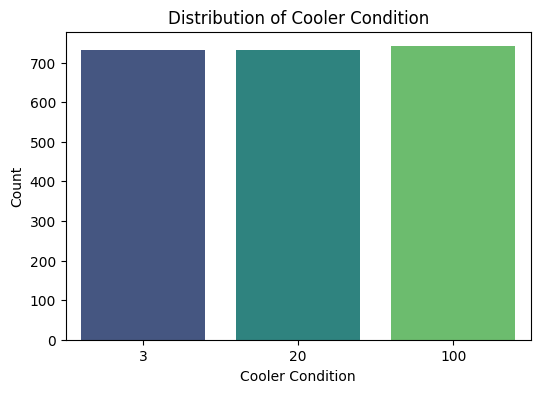

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(x=df["cool_cond"], palette="viridis")
plt.xlabel("Cooler Condition")
plt.ylabel("Count")
plt.title("Distribution of Cooler Condition")
plt.show()

## Correlation Heatmap

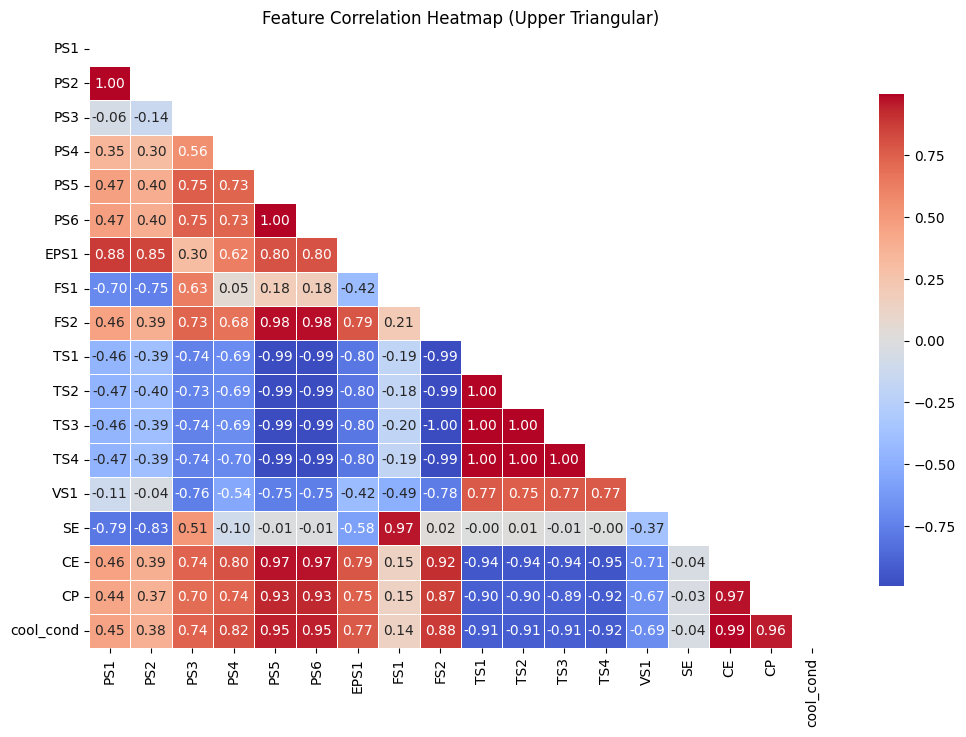

In [9]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5, cbar_kws={"shrink": .8})
plt.title("Feature Correlation Heatmap (Upper Triangular)")
plt.show()

## Sensor Data Distribution

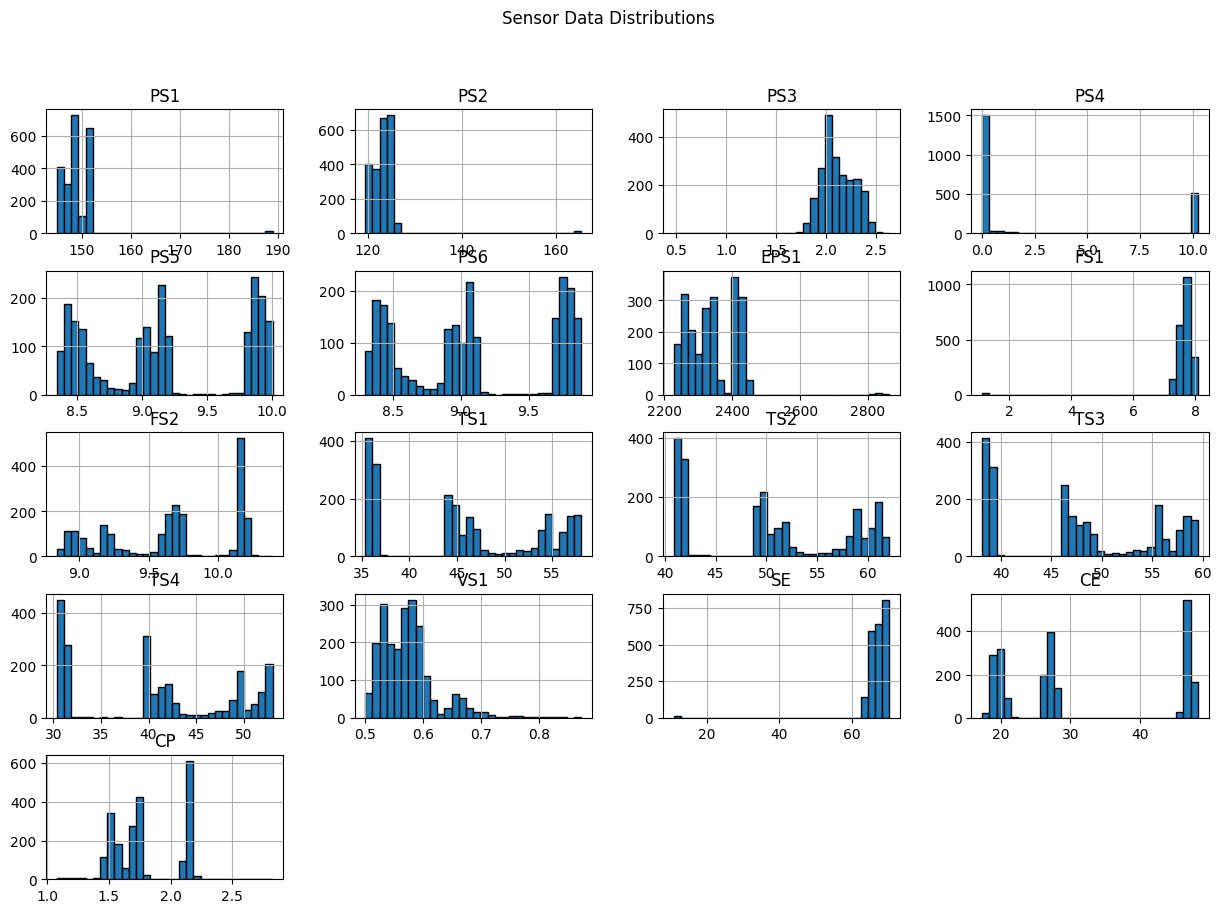

In [10]:
df.drop(columns=["cool_cond"]).hist(figsize=(15, 10), bins=30, edgecolor="black")
plt.suptitle("Sensor Data Distributions")
plt.show()

##  Pair Plot for Feature Relationships

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

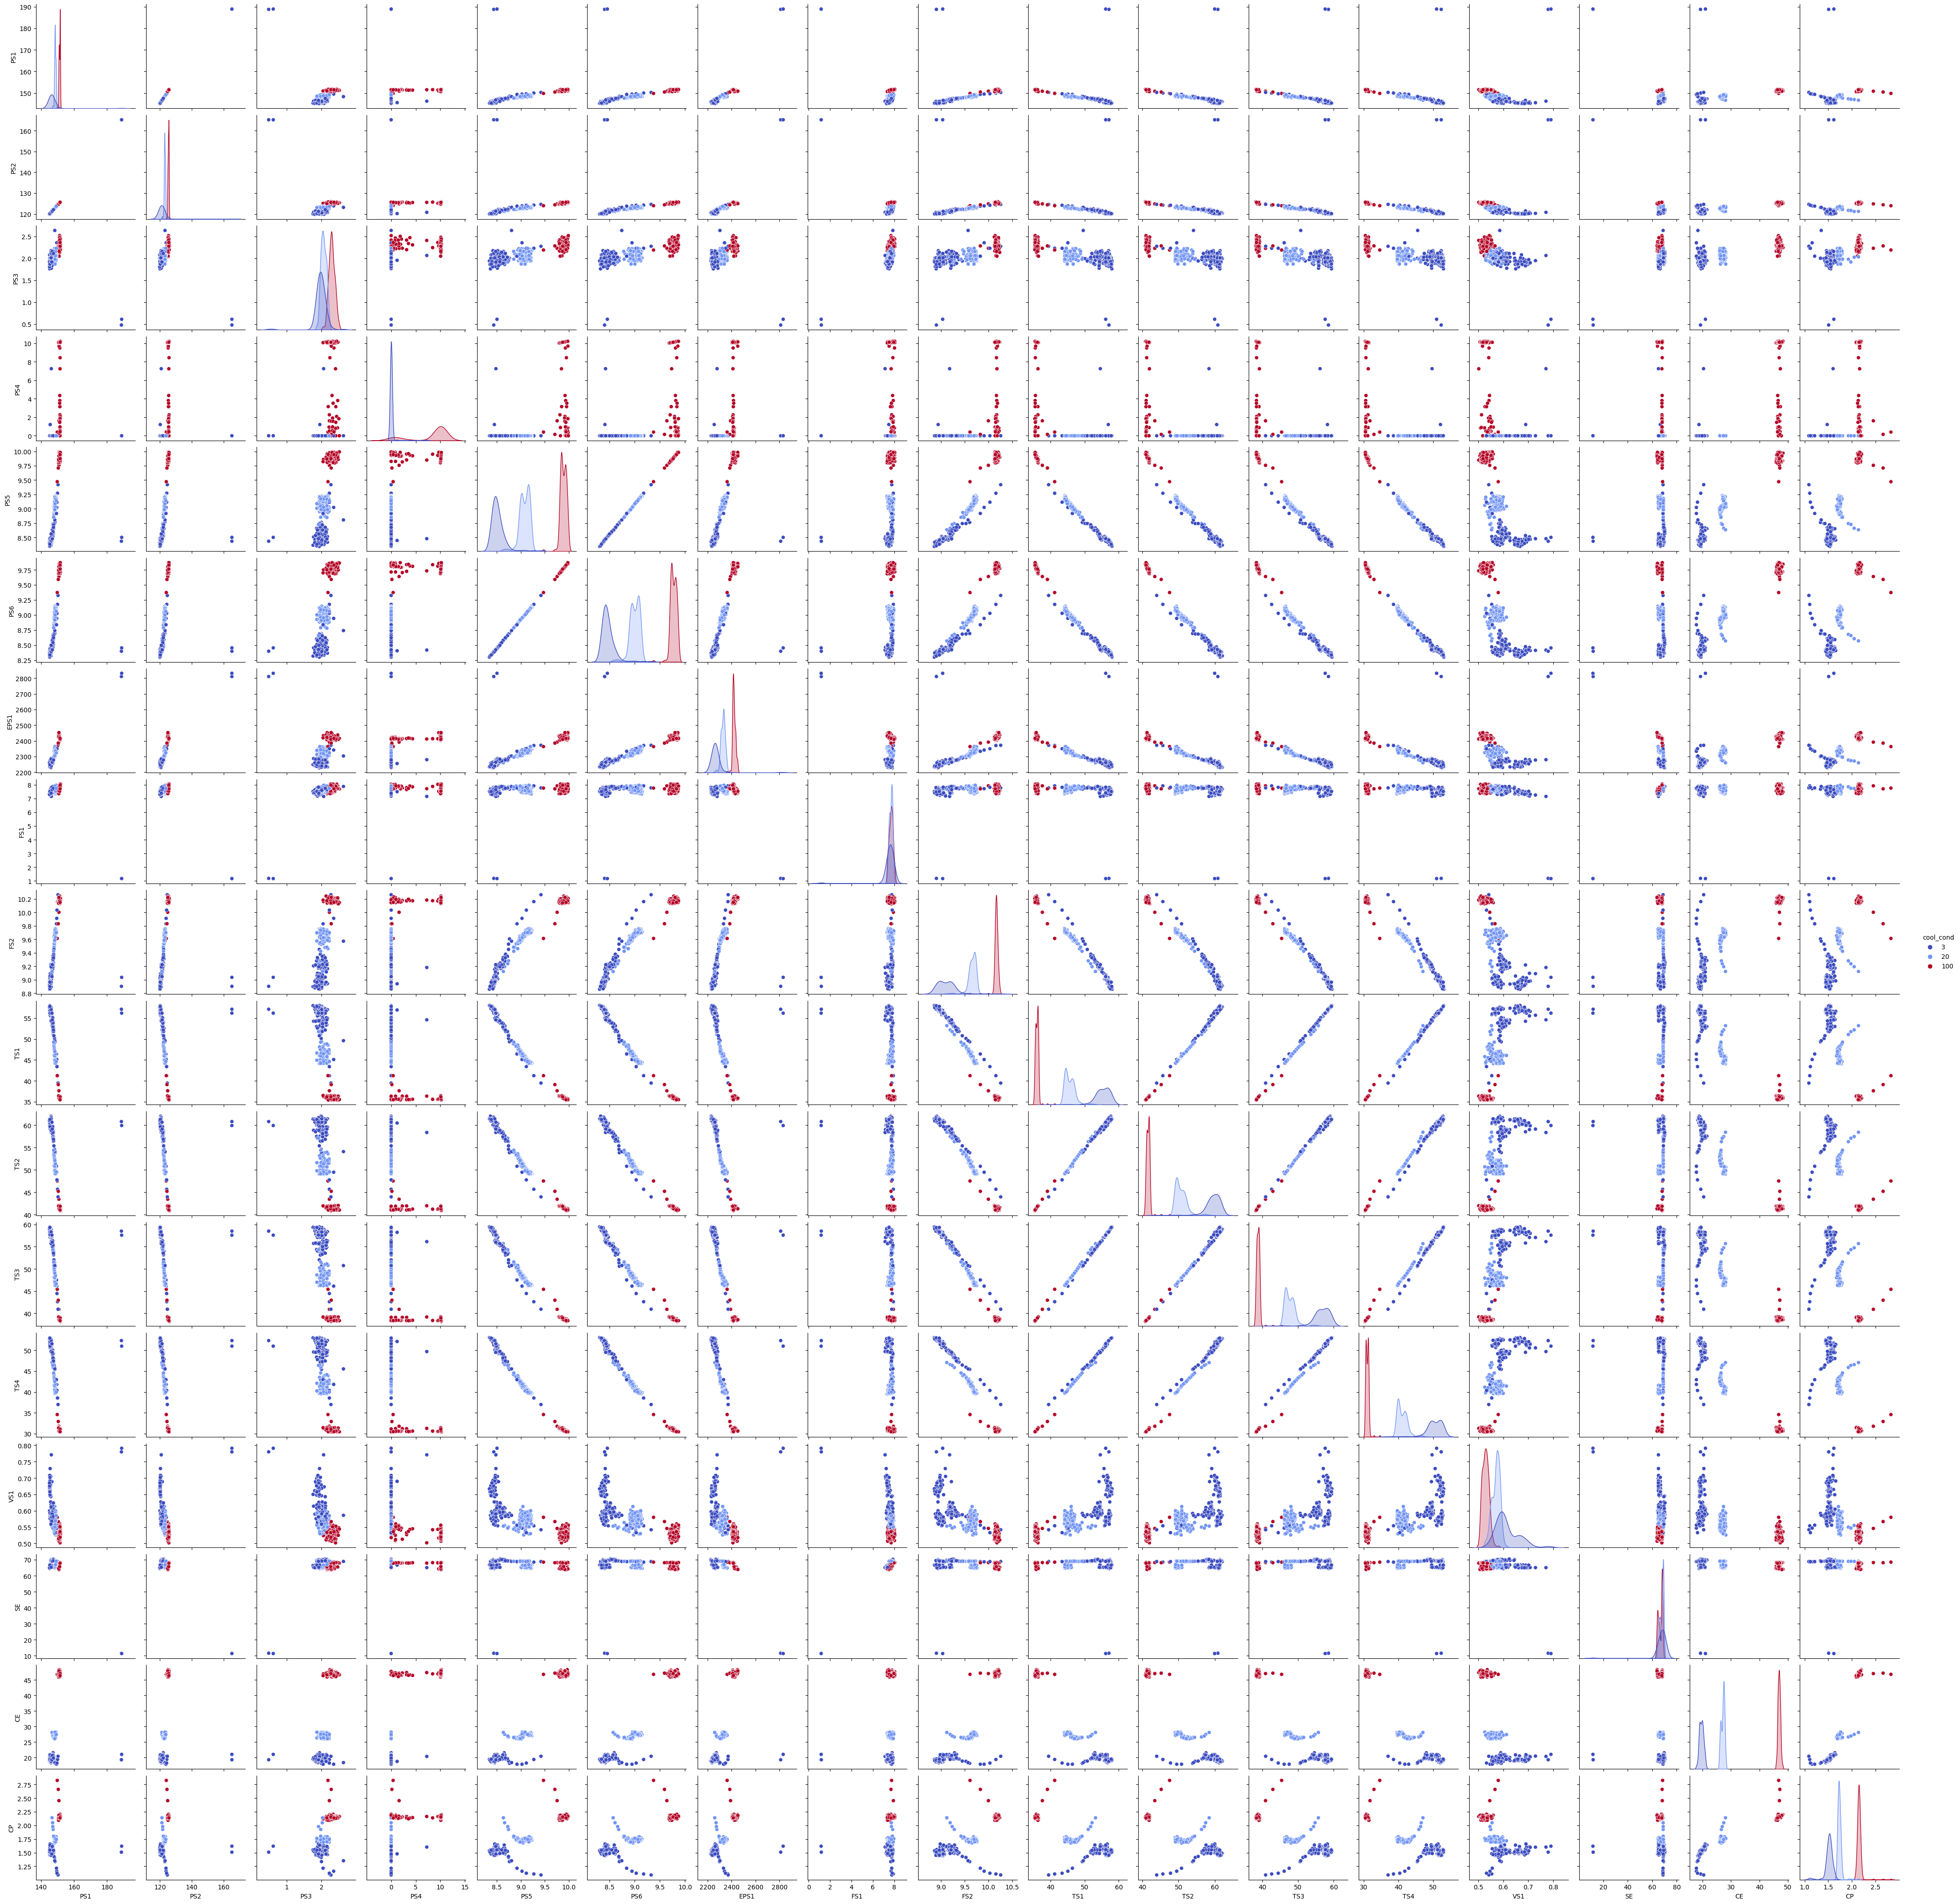

In [11]:
sns.pairplot(df.sample(500), hue="cool_cond", diag_kind="kde", palette="coolwarm")
plt.show()

## Feature Engineering

### Remove Low-Variance Features

In [15]:
X = df.drop(columns=["cool_cond"])  
y = df["cool_cond"]  

# Applying Variance Threshold
selector = VarianceThreshold(threshold=0.01)
X_selected = selector.fit_transform(X)

selected_columns = X.columns[selector.get_support()] 
df_reduced = pd.DataFrame(X_selected, columns=selected_columns)

df_reduced["cool_cond"] = y  

print("Reduced dataset shape:", df_reduced.shape)

Reduced dataset shape: (2205, 17)


## Handling Skewed Features

In [20]:
skewed_features = df_reduced.drop(columns=["cool_cond"]).apply(lambda x: skew(x)).sort_values(ascending=False)
high_skew = skewed_features[abs(skewed_features) > 1].index
df_reduced[high_skew] = np.log1p(df_reduced[high_skew])  

In [21]:
scaler = StandardScaler()
df_reduced.iloc[:, :-1] = scaler.fit_transform(df_reduced.drop(columns=["cool_cond"]))

## Feature Selection via Mutual Information

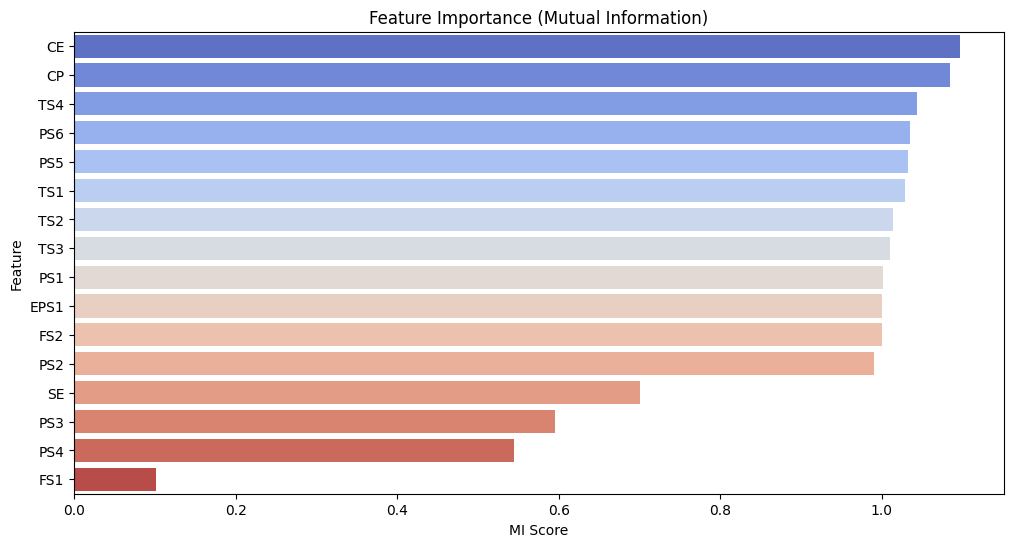

In [22]:
mi_scores = mutual_info_classif(df_reduced.drop(columns=["cool_cond"]), df["cool_cond"])
mi_df = pd.DataFrame({"Feature": df_reduced.columns[:-1], "MI Score": mi_scores})
mi_df = mi_df.sort_values(by="MI Score", ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x="MI Score", y="Feature", data=mi_df, palette="coolwarm")
plt.title("Feature Importance (Mutual Information)")
plt.show()

## SPLIT DATA

In [24]:
X = df_reduced.drop(columns=["cool_cond"])
y = df_reduced["cool_cond"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Training Model

In [38]:
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

Accuracy: 1.0

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00       147
          20       1.00      1.00      1.00       146
         100       1.00      1.00      1.00       148

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



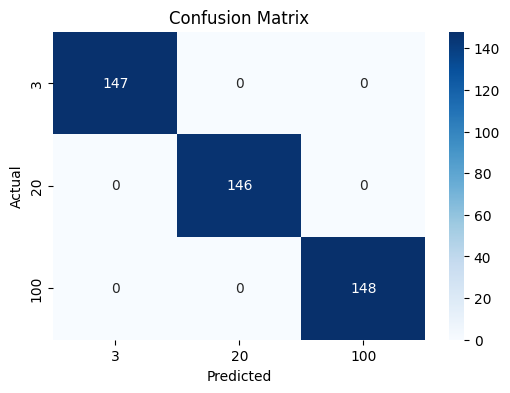

In [39]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## GBM

In [40]:
gbm_model = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3)
gbm_model.fit(X_train, y_train)

y_pred_gbm = gbm_model.predict(X_test)
y_pred_gbm_proba = gbm_model.predict_proba(X_test)[:, 1]

Accuracy: 0.9977324263038548

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00       147
          20       1.00      0.99      1.00       146
         100       0.99      1.00      1.00       148

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



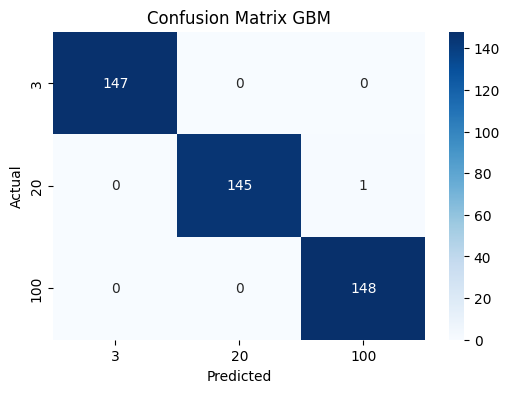

In [41]:
print("Accuracy:", accuracy_score(y_test, y_pred_gbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gbm))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_gbm), annot=True, fmt='d', cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix GBM")
plt.show()

In [42]:
from sklearn.neural_network import MLPClassifier

mlp_model = MLPClassifier(hidden_layer_sizes=(100,), max_iter=1000, random_state=42)
mlp_model.fit(X_train, y_train)

MLPClassifier(max_iter=1000, random_state=42)

Accuracy: 0.9977324263038548

Classification Report:
               precision    recall  f1-score   support

           3       1.00      1.00      1.00       147
          20       1.00      0.99      1.00       146
         100       0.99      1.00      1.00       148

    accuracy                           1.00       441
   macro avg       1.00      1.00      1.00       441
weighted avg       1.00      1.00      1.00       441



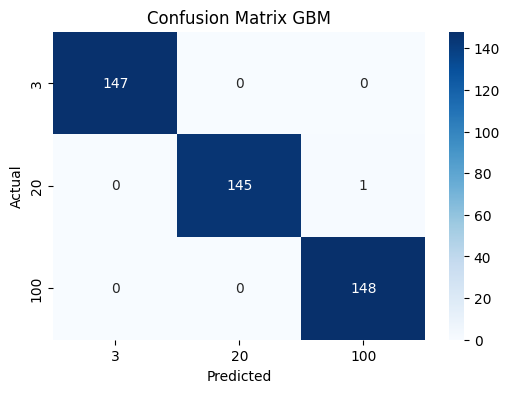

In [43]:
y_pred_mlp = mlp_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_gbm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_gbm))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_gbm), annot=True, fmt='d', cmap="Blues", xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix GBM")
plt.show()